In [2]:
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install scikit-learn
!pip install matplotlib
!pip install scipy
!pip install pickle-mixin
!pip install seaborn
!pip install flask-ngrok
!pip install flask

  Preparing metadata (setup.py) ... done
  Created wheel for pickle-mixin: filename=pickle_mixin-1.0.2-py3-none-any.whl size=5988 sha256=0704bbdef8864e50762c2b2a01c0134adcc5ef3d80200c8b3320c0a9d82f2ad1
  Stored in directory: /root/.cache/pip/wheels/69/e2/5c/da8f96a08c63469bc8b10e206cd4c78e8886d8acb8699f84c2
Successfully built pickle-mixin


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# import MultiColumnLabelEncoder # This module was not found. Please install it (e.g., !pip install some-package-name) or define it if it's a custom module.
from sklearn.model_selection import train_test_split
from sklearn.linear_model  import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import pickle

In [6]:
from sklearn.preprocessing import LabelEncoder

class MultiColumnLabelEncoder:
    def __init__(self, columns=None):
        self.columns = columns # list of column names to encode
        self.encoders = {}

    def fit(self, X, y=None):
        self.encoders = {col: LabelEncoder() for col in self.columns}
        for col in self.columns:
            self.encoders[col].fit(X[col])
        return self

    def transform(self, X):
        output = X.copy()
        for col in self.columns:
            output[col] = self.encoders[col].transform(X[col])
        return output

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

In [7]:
df = pd.read_csv('/content/garments_worker_productivity.csv')
display(df.head())

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


Text(0.5, 1.0, 'Correlation Heatmap')

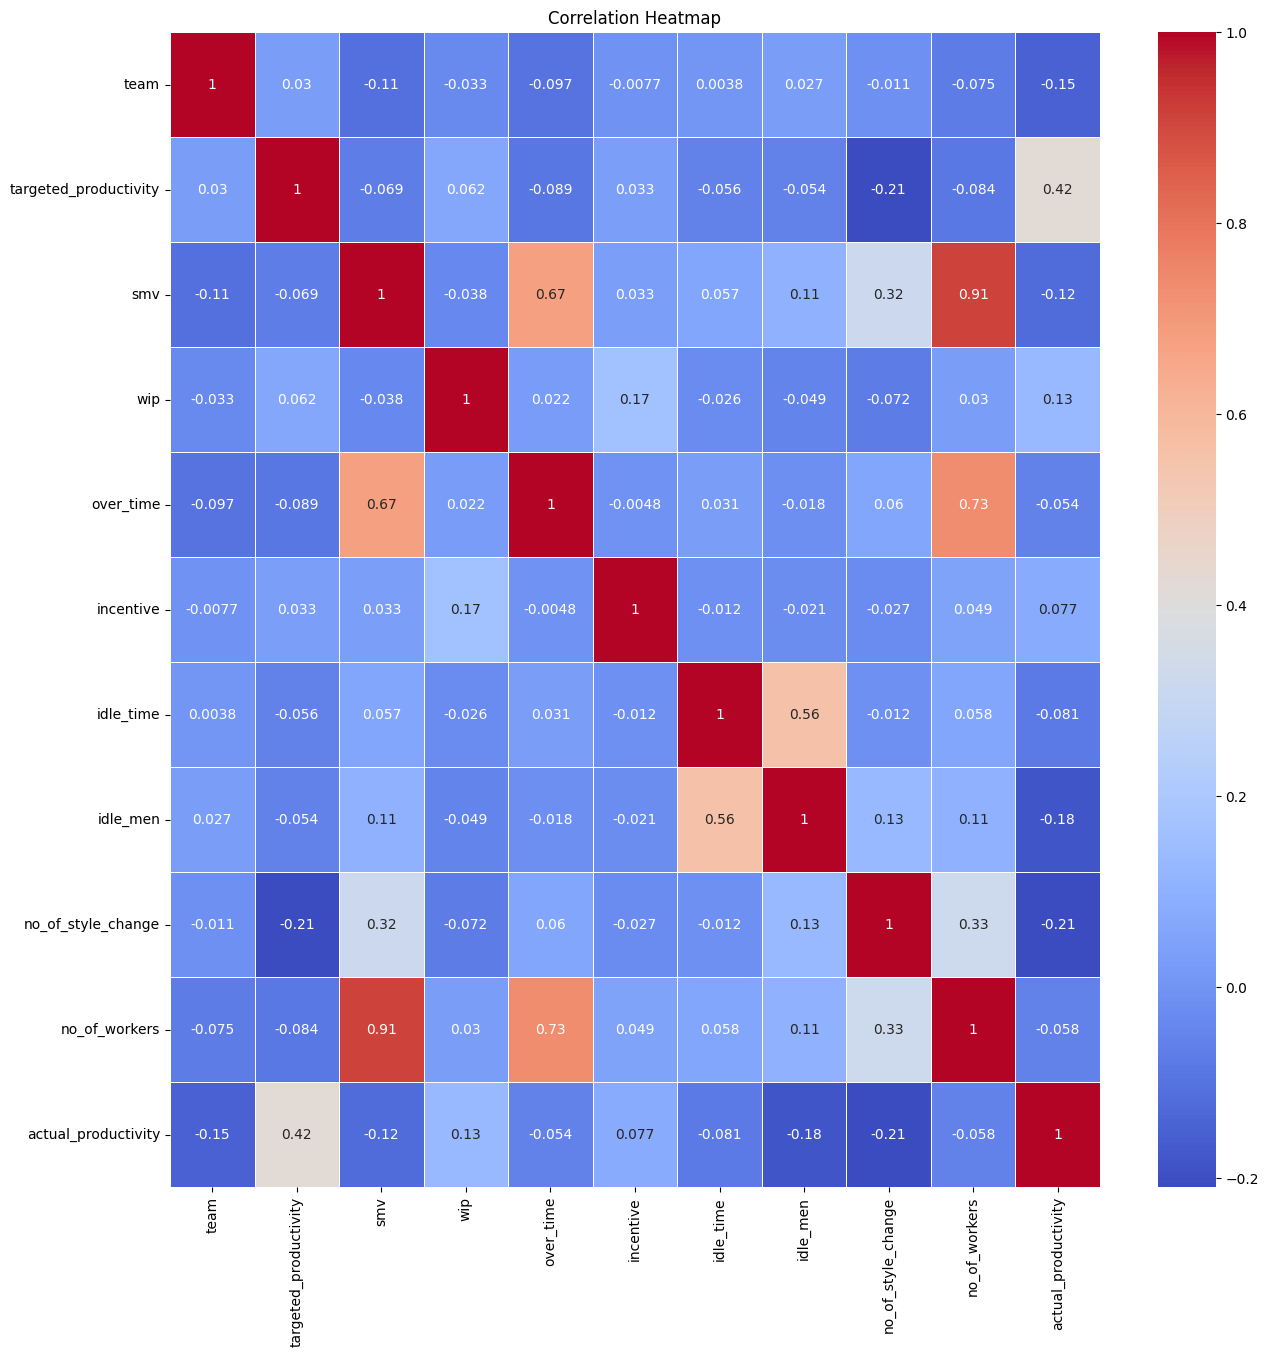

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',linewidths=.5,ax=ax)
plt.title('Correlation Heatmap')

In [10]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [11]:
df.shape

(1197, 15)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [14]:
df.isnull().sum()

,0
date,0
quarter,0
department,0
day,0
team,0
targeted_productivity,0
smv,0
wip,506
over_time,0
incentive,0


In [15]:
df.drop(['wip'],axis=1,inplace=True)

In [16]:
df.isnull().sum()

,0
date,0
quarter,0
department,0
day,0
team,0
targeted_productivity,0
smv,0
over_time,0
incentive,0
idle_time,0


In [20]:
df['date'] = pd.to_datetime(df['date'])
df.date

,date
0,2015-01-01
1,2015-01-01
2,2015-01-01
3,2015-01-01
4,2015-01-01
...,...
1192,2015-03-11
1193,2015-03-11
1194,2015-03-11
1195,2015-03-11


In [24]:
if 'date' in df.columns:
    df['month'] = df['date'].dt.month
    df.drop(['date'],axis=1,inplace=True)
else:
    print("'date' column not found, skipping month extraction and drop.")
df.head()

'date' column not found, skipping month extraction and drop.


,quarter,department,day,team,targeted_productivity,smv,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,month
0,Quarter1,sweing,Thursday,8,0.80,26.16,7080,98,0.0,0,0,59.0,0.940725,1
1,Quarter1,finishing,Thursday,1,0.75,3.94,960,0,0.0,0,0,8.0,0.886500,1
2,Quarter1,sweing,Thursday,11,0.80,11.41,3660,50,0.0,0,0,30.5,0.800570,1
3,Quarter1,sweing,Thursday,12,0.80,11.41,3660,50,0.0,0,0,30.5,0.800570,1
4,Quarter1,sweing,Thursday,6,0.80,25.90,1920,50,0.0,0,0,56.0,0.800382,1


In [25]:
df.month

,month
0,1
1,1
2,1
3,1
4,1
...,...
1192,3
1193,3
1194,3
1195,3


In [26]:
df['department'].value_counts()

,count
department,
sweing,691
finishing,257
finishing,249


In [27]:
df['department']=df['department'].apply(lambda x: 'finishing' if x.replace(" ","")=='finishing' else 'sweing')

In [28]:
df['department'].value_counts()

,count
department,
sweing,691
finishing,506


In [32]:
Mcle = MultiColumnLabelEncoder(columns=df.select_dtypes(include=['object', 'category']).columns)
df = Mcle.fit_transform(df)

In [33]:
x=df.drop('actual_productivity',axis=1)
y=df['actual_productivity']

In [34]:
X=x.to_numpy()
X

array([[ 0. ,  1. ,  3. , ...,  0. , 59. ,  1. ],
       [ 0. ,  0. ,  3. , ...,  0. ,  8. ,  1. ],
       [ 0. ,  1. ,  3. , ...,  0. , 30.5,  1. ],
       ...,
       [ 1. ,  0. ,  5. , ...,  0. ,  8. ,  3. ],
       [ 1. ,  0. ,  5. , ...,  0. , 15. ,  3. ],
       [ 1. ,  0. ,  5. , ...,  0. ,  6. ,  3. ]])

In [37]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8,random_state=0)

In [39]:
from sklearn.linear_model import LinearRegression
model_lr=LinearRegression()

In [42]:
model_lr.fit(x_train, y_train)
pred_test=model_lr.predict(x_test)
print("test_MSE:",mean_squared_error(y_test,pred_test))
print("test_MAE:",mean_absolute_error(y_test,pred_test))
print("R2_score:",r2_score(y_test,pred_test))

test_MSE: 0.020952954761875545
test_MAE: 0.10636001215549953
R2_score: 0.2913123154775583


In [43]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=200,max_depth=5)

In [45]:
model_rf.fit(x_train, y_train)
pred = model_rf.predict(x_test)
print("test_MSE:",mean_squared_error(y_test,pred))
print("test_MAE:",mean_absolute_error(y_test,pred))
print("R2_score:{}".format(r2_score(y_test,pred)))

test_MSE: 0.015616149440956567
test_MAE: 0.08608161989711059
R2_score:0.47181803644206877


In [46]:
import xgboost as xgb
model_xgb = xgb.XGBRegressor(n_estimators=200,max_depth=5,learning_rate=0.1)

In [47]:
model_xgb.fit(x_train, y_train)
pred = model_xgb.predict(x_test)
print("test_MSE:",mean_squared_error(y_test,pred))
print("test_MAE:",mean_absolute_error(y_test,pred))
print("R2_score:{}".format(r2_score(y_test,pred)))

test_MSE: 0.015048792808164598
test_MAE: 0.07904341491293163
R2_score:0.4910076286958249
